# Import packages

In [1]:
# %pip install sodapy
# %pip install geopandas
# %pip install ipywidgets

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sodapy import Socrata
import requests

import json
import os
import shapely
import folium

env = os.environ

# Getting the data

In [3]:
# Settings
api_key = env.get("API_KEY")
app_token = env.get("APP_TOKEN")
secret_key = env.get("SECRET_KEY")

DATASET_ID = "kufs-yh3x"
limit = 100000
offset = 0

Filter = 'Manhattan'

client = Socrata("data.ny.gov", app_token = app_token)


In [4]:
# getting the data with api call
# all_results = []

# while True:
#     batch = client.get(
#         DATASET_ID,
#         where = "borough = 'Manhattan'",
#         limit=limit,
#         offset=offset
#     )
#     if not batch:
#         break
#     all_results.extend(batch)
#     print(f"Downloaded {len(batch)} records (offset {offset})")
#     offset += limit

# data_df = pd.DataFrame(all_results)

# saving the data
# data_df.to_csv("Manhattan_Bus_data.csv")

# loading the data
data_df = pd.read_csv("Manhattan_Bus_data.csv", index_col = 0)

## GEOJSON Data

In [5]:
DATASET_ID = "pri4-ifjk"
limit = 10
offset = 0

all_results = []

## Getting the data
# while True:
#     batch = client.get(
#         DATASET_ID,
#         limit=limit,
#         offset=offset
#     )
#     if not batch:
#         break
#     all_results.extend(batch)
#     print(f"Downloaded {len(batch)} records (offset {offset})")
#     offset += limit


## Converting the results into features
# features = []

# for record in all_results:
#     feature = {
#         "type": "Feature",
#         "geometry": record["the_geom"],
#         "properties": {k: v for k, v in record.items() if k != "the_geom" and k != "zcta" and k != "label"}
#     }
#     features.append(feature)


# Create GeoDataFrame
# gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
# gdf.to_file("geo_data_converted.geojson", driver="GeoJSON")

# loading the data
gdf = gpd.read_file("geo_data_converted.geojson")

## Creating point data

### Matching points to Zip codes

In [6]:
# Creating dataframe of points (keep original index)
points_df = data_df[["timepoint_stop_latitude", "timepoint_stop_longitude"]].copy()

# Ensure numeric
points_df["timepoint_stop_latitude"] = pd.to_numeric(points_df["timepoint_stop_latitude"], errors='coerce')
points_df["timepoint_stop_longitude"] = pd.to_numeric(points_df["timepoint_stop_longitude"], errors='coerce')


# Create geometry (lon, lat order for Point)
points_df["geometry"] = [
    shapely.geometry.Point(lon, lat) 
    for lon, lat in zip(points_df["timepoint_stop_longitude"], points_df["timepoint_stop_latitude"])
]

# Convert to GeoDataFrame
gdf_points = gpd.GeoDataFrame(points_df, geometry='geometry', crs='EPSG:4326')

# Spatial join: find which ZIP polygon each point falls within
joined = gpd.sjoin(gdf_points, gdf[['modzcta', 'geometry']], how='left', predicate='within')

# Add ZIP code back to original data_df using the preserved index
data_df['zip_code'] = None  # initialize column
data_df.loc[joined.index, 'zip_code'] = joined['modzcta'].values

In [7]:
def _make_linestring(row):
    lat1 = row.get("timepoint_stop_latitude")
    lon1 = row.get("timepoint_stop_longitude")
    lat2 = row.get("next_timepoint_stop_latitude")
    lon2 = row.get("next_timepoint_stop_longitude")
    
    return shapely.geometry.LineString([(lon1, lat1), (lon2, lat2)])

# Making points to LineStrings
data_df["LineString"] = data_df.apply(_make_linestring, axis=1)

# Cleaning the data

In [8]:
# chaging timestamp to datetime and making it the index - so I can filter later
data_df["timestamp"] = pd.to_datetime(data_df["timestamp"])
data_df.set_index("timestamp", inplace = True)

# Analyzing the data

In [9]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 606189 entries, 2025-03-01 12:00:00 to 2025-06-01 12:00:00
Data columns (total 25 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   year                              606189 non-null  int64  
 1   month                             606189 non-null  int64  
 2   day_of_week                       606189 non-null  object 
 3   hour_of_day                       606189 non-null  int64  
 4   route_id                          606189 non-null  object 
 5   direction                         606189 non-null  object 
 6   borough                           606189 non-null  object 
 7   route_type                        606189 non-null  object 
 8   stop_order                        606189 non-null  int64  
 9   timepoint_stop_id                 606189 non-null  int64  
 10  timepoint_stop_name               606189 non-null  object 
 11  timepoint_stop_lat

## Plotting the data

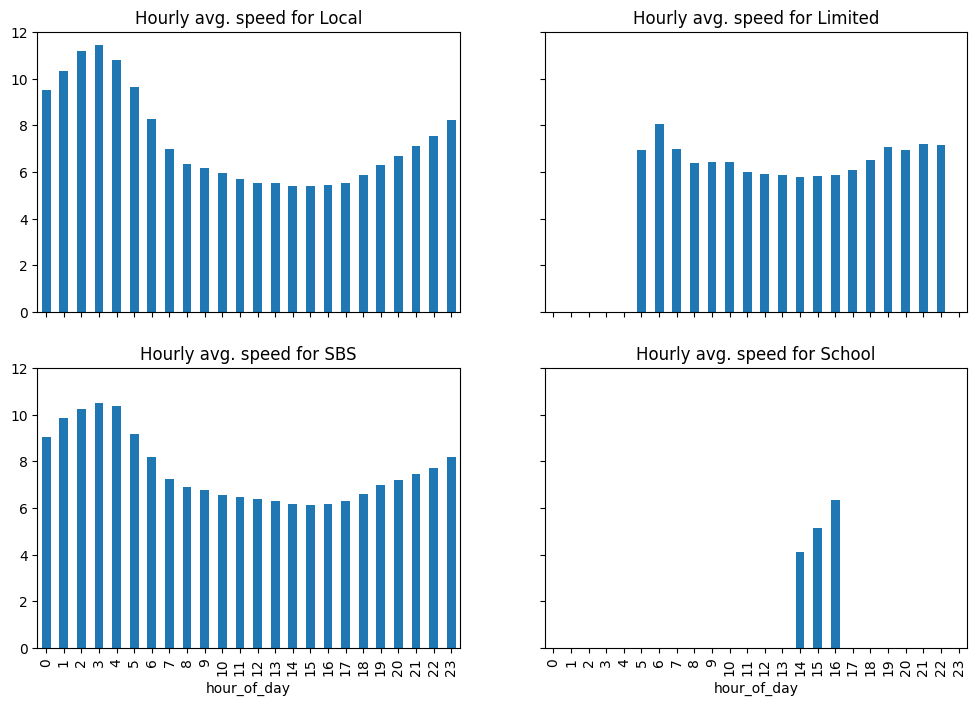

In [10]:
figs, axes = plt.subplots(2,2, figsize = (12,8), sharex = True, sharey = True)

options = list(data_df["route_type"].unique())
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    condition = options[i]
    subset = data_df[data_df["route_type"] == condition]
    subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "bar", ax = ax)
    ax.set_title(f"Hourly avg. speed for {condition}")


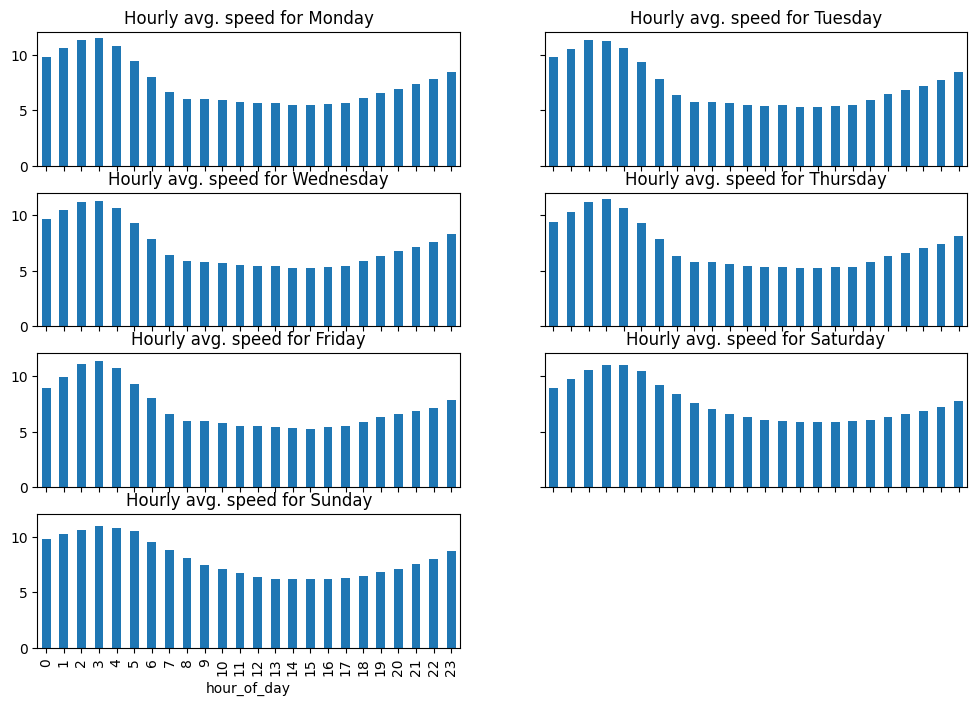

In [11]:
figs, axes = plt.subplots(4,2, figsize = (12,8), sharex = True, sharey = True)

options = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    if i > len(condition):
        ax.set_visible(False)
        break
    condition = options[i]
    subset = data_df[data_df["day_of_week"] == condition]
    subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "bar", ax = ax)
    ax.set_title(f"Hourly avg. speed for {condition}")


# Plotting data on map

In [12]:
# The number of stops fluctuates between the months 
## why is that?
test = data_df[(data_df["route_id"] == "M4") & (data_df["month"] == 9)].sort_values(by = ["hour_of_day", "stop_order"])

test["stop_order"].sort_values().unique()

array([ 1, 10, 12, 22, 25, 26, 27, 33, 39, 43, 46, 47, 49, 54, 59, 65, 70,
       77])

In [16]:
from folium.plugins import MarkerCluster

def plot_bus_routes(data_df, month=None, weekday=None, route_id=None, hour = None):
    """
    Plot NYC bus routes with color indicating average speed.
    """

    # ---- Filter data ----
    df = data_df.copy()
    if month is not None:
        df = df[df["month"] == month]
    if weekday is not None:
        df = df[df["day_of_week"] == weekday]
    if route_id is not None:
        df = df[df["route_id"] == route_id]
    if hour is not None:
        df = df[df["hour_of_day"] == hour]

    # ---- Create colors ----
    routes = sorted(df['route_id'].dropna().unique())
    cmap = plt.get_cmap('Paired', len(routes))    
    route_colors = {r: mcolors.to_hex(cmap(i)) for i, r in enumerate(routes)}

    # ---- Compute speed range ----
    speeds = df["average_road_speed"].dropna()
    min_s, max_s = speeds.min(), speeds.max()
    norm = mcolors.Normalize(vmin=min_s, vmax=max_s)
    cmap = plt.get_cmap("RdYlGn")

    # ---- Initialize map ----
    m = folium.Map(location=[40.7831, -73.9712], zoom_start=12, tiles="CartoDB positron")
    marker_cluster = MarkerCluster(name="Stops", disableClusteringAtZoom=12, maxClusterRadius=60).add_to(m)

    # ---- Plot routes ----
    for _, row in df.iterrows():
        speed = row["average_road_speed"]
        
        # Getting the coordinates
        lat1 = row.get("timepoint_stop_latitude")
        lon1 = row.get("timepoint_stop_longitude")
        lat2 = row.get("next_timepoint_stop_latitude")
        lon2 = row.get("next_timepoint_stop_longitude")
        
        line_coords = [[lat1, lon1], [lat2, lon2]]

        color = mcolors.to_hex(cmap(norm(speed)))
        color_route = route_colors.get(row["route_id"])
        
        # creating stop names for markers in loop
        stop_names = [row["timepoint_stop_name"], row["next_timepoint_stop_name"]]

        for i in range(2):
            folium.CircleMarker(
                location = line_coords[i],
                radius = 7,
                color= color_route,
                fill_color = color_route,
                fill = True,
                popup=f"Route: {row['route_id']} \n Stop: {stop_names[i]}",
            ).add_to(marker_cluster)

        folium.PolyLine(
            locations = line_coords,
            color = color,
            weight = 3,
            opacity = 0.8,
            popup=f"{row['route_id']} | {speed:.1f} mph"
        ).add_to(m)

    return m


# Examples:
# Plot specific route M4 for January on Monday
m = plot_bus_routes(data_df, month=1, weekday="Tuesday", hour = 16)
m

In [14]:
# Save map to HTML file to view in browser (workaround for trust issues)
if m is not None:
    m.save("bus_routes_map.html")
    print("Map saved to bus_routes_map.html")
    print("Open this file in your browser to view the map")


Map saved to bus_routes_map.html
Open this file in your browser to view the map


## Interactive Map with Controls and Animation

In [15]:
# import ipywidgets as widgets
# from IPython.display import display, HTML
# import time

# # Get unique values for dropdowns
# routes = sorted(data_df['route_id'].unique().tolist())
# months = sorted(data_df['month'].unique().tolist())
# weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# hours = list(range(24))

# # Create dropdown widgets
# route_dropdown = widgets.Dropdown(
#     options=['All Routes'] + routes,
#     value='All Routes',
#     description='Route:',
#     style={'description_width': 'initial'}
# )

# month_dropdown = widgets.Dropdown(
#     options=['All Months'] + months,
#     value=1,
#     description='Month:',
#     style={'description_width': 'initial'}
# )

# weekday_dropdown = widgets.Dropdown(
#     options=['All Weekdays'] + weekdays,
#     value='Monday',
#     description='Weekday:',
#     style={'description_width': 'initial'}
# )

# hour_slider = widgets.IntSlider(
#     value=12,
#     min=0,
#     max=23,
#     step=1,
#     description='Hour:',
#     continuous_update=False,
#     style={'description_width': 'initial'}
# )

# # Animation controls
# play_button = widgets.Play(
#     value=0,
#     min=0,
#     max=23,
#     step=1,
#     interval=1000,  # 1 second per frame
#     description="Animate Hours",
#     disabled=False
# )

# widgets.jslink((play_button, 'value'), (hour_slider, 'value'))

# # Output widget for the map
# output = widgets.Output()

# def update_map(change=None):
#     """Update the map based on dropdown selections"""
#     with output:
#         output.clear_output(wait=True)
        
#         # Get values from widgets
#         route = None if route_dropdown.value == 'All Routes' else route_dropdown.value
#         month = None if month_dropdown.value == 'All Months' else month_dropdown.value
#         weekday = None if weekday_dropdown.value == 'All Weekdays' else weekday_dropdown.value
#         hour = hour_slider.value
        
#         # Create the map
#         m = plot_bus_routes(data_df, month=month, weekday=weekday, route_id=route, hour=hour)
        
#         if m is not None:
#             display(m)
#         else:
#             print("No data available for selected filters")

# # Attach the update function to all widgets
# route_dropdown.observe(update_map, names='value')
# month_dropdown.observe(update_map, names='value')
# weekday_dropdown.observe(update_map, names='value')
# hour_slider.observe(update_map, names='value')

# # Create layout
# controls = widgets.VBox([
#     widgets.HBox([route_dropdown, month_dropdown, weekday_dropdown]),
#     widgets.HBox([play_button, hour_slider])
# ])

# # Display the interface
# display(controls)
# display(output)

# # Initial map
# update_map()
